# Increasing bathymetry in South Hood Canal and Lynch Cove

In [2]:
import cmocean.cm as cm 
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import xarray as xr
from pathlib import Path

from salishsea_tools import bathy_tools, nc_tools
from scipy.ndimage import distance_transform_edt, gaussian_filter

%matplotlib inline


In [3]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
def get_ij(ds_map, lat0, lon0):
    j = int(ds_map.jj.sel(lats=lat0, lons=lon0, method='nearest').values)
    i = int(ds_map.ii.sel(lats=lat0, lons=lon0, method='nearest').values)
    return j, i

j_Sis, i_Sis = get_ij(grid_lons_lats, 47.356205, -123.02487)
j_LyC, i_LyC = get_ij(grid_lons_lats, 47.39814833, -122.92959167)

In [4]:
model_file = "/ocean/atall/MOAD/grid/bathymetry_202310b.nc"

xminLC, xmaxLC = -123.2, -122.83
yminLC, ymaxLC = 47.33, 47.45

MIN_DEPTH = 4
DELTA_MAX = 10   # max deepening
SMOOTH_FACTOR = 0.2
RMAX = 0.8

# For Lynch Cove and Sisters Points
USE_OBS_POINTS = True


In [5]:
# Load model grid and bathymetry
ds = nc.Dataset(model_file)

lon = ds.variables['nav_lon'][:]
lat = ds.variables['nav_lat'][:]
old_bathy = ds.variables['Bathymetry'][:]

ocean_mask = old_bathy > 0

# LC mask
mask_LC = (
    (lon > xminLC) & (lon < xmaxLC) &
    (lat > yminLC) & (lat < ymaxLC) &
    ocean_mask
)

# Distance transform: distance to nearest non-HC-LC point
dist = distance_transform_edt(mask_LC)

dist_max = np.nanmax(dist)
if dist_max == 0:
    raise ValueError("Mask too small")

dist_norm = dist / dist_max

# nonlinear taper (important)
weight = dist_norm**2

# Base deepening field
delta_field = DELTA_MAX * weight
delta_field[~mask_LC] = 0

# Observation-based forcing
bathy_forcing = np.zeros_like(old_bathy)

if USE_OBS_POINTS:
    obs_points = [
        {"j": int(j_LyC), "i": int(i_LyC), "depth": 22.0},
        {"j": int(j_Sis), "i": int(i_Sis), "depth": 55.0},
    ]

    sigma = 2  # spatial spread

    for pt in obs_points:
        j, i, target = pt["j"], pt["i"], pt["depth"]

        if old_bathy[j, i] <= 0:
            continue

        delta = target - old_bathy[j, i]
        if delta <= 0:
            continue

        impulse = np.zeros_like(old_bathy)
        impulse[j, i] = delta

        bump = gaussian_filter(impulse, sigma=sigma)

        bathy_forcing += bump


In [6]:
# Combine fields
bathy_new = old_bathy.copy()

bathy_new += delta_field
bathy_new += bathy_forcing

# enforce minimum depth
bathy_new[bathy_new < MIN_DEPTH] = MIN_DEPTH
bathy_new[~ocean_mask] = np.nan

# Smoothing
ps_masked = np.ma.masked_array(bathy_new, ~ocean_mask)

smoothed = bathy_tools.smooth(
    ps_masked,
    max_norm_depth_diff=RMAX,
    smooth_factor=SMOOTH_FACTOR
)


In [7]:
# Enforce constraints
final_bathy = smoothed.copy()

mask_fix = mask_LC & ocean_mask

# ensure always deeper than original
final_bathy[mask_fix] = np.maximum(
    final_bathy[mask_fix],
    old_bathy[mask_fix] + 0.1
)

# enforce observation points exactly
if USE_OBS_POINTS:
    for pt in obs_points:
        j, i, target = pt["j"], pt["i"], pt["depth"]
        final_bathy[j, i] = max(final_bathy[j, i], target)


In [8]:
# Validation
diff = final_bathy - old_bathy


print("Max depth old bathy:", np.nanmax(old_bathy[mask_LC]))
print("Max depth new bathy:", np.nanmax(final_bathy[mask_LC]))
print("Min depth difference:", np.nanmin(diff[mask_LC]))
print("Mean depth difference:", np.nanmean(diff[mask_LC]))
if np.nanmin(diff[mask_LC]) <= 0:
    print("Negative differences still present")

Max depth old bathy: 128.3125
Max depth new bathy: 130.53472222222223
Min depth difference: 0.09999999999999432
Mean depth difference: 2.4786190515568647


/tmp/ipykernel_233633/2516965446.py:9: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m0 = ax[0].pcolormesh(lon, lat, old_bathy, cmap=cmap, vmin=vmin, vmax=vmax)
/tmp/ipykernel_233633/2516965446.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m1 = ax[1].pcolormesh(lon, lat, final_bathy, cmap=cmap, vmin=vmin, vmax=vmax)
/tmp/ipykernel_233633/2516965446.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit

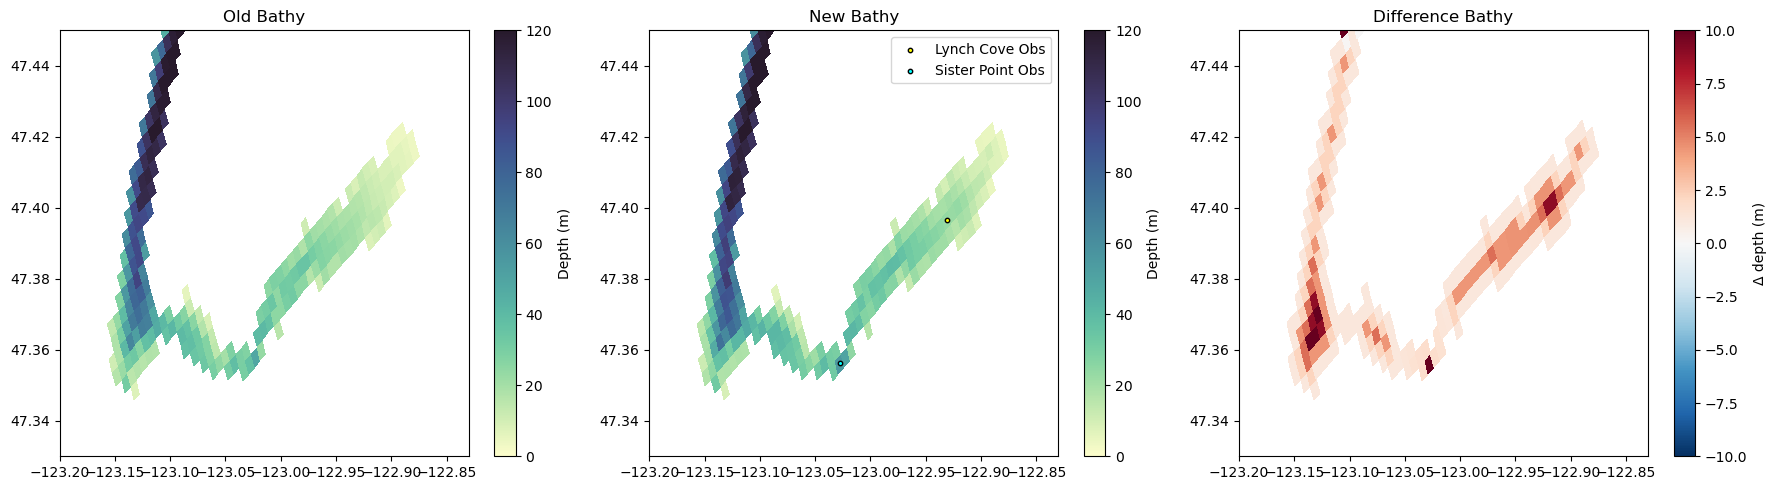

In [35]:
# Figures
cmap = cm.deep
cmap.set_bad('white')

vmin, vmax = 0, 120

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

m0 = ax[0].pcolormesh(lon, lat, old_bathy, cmap=cmap, vmin=vmin, vmax=vmax)
ax[0].set_title("Old Bathy")
fig.colorbar(m0, ax=ax[0], label="Depth (m)")
m1 = ax[1].pcolormesh(lon, lat, final_bathy, cmap=cmap, vmin=vmin, vmax=vmax)
ax[1].set_title("New Bathy")
ax[1].scatter(
    [lon[j_LyC,i_LyC]], [lat[j_LyC,i_LyC]], color='yellow', edgecolor='black', s=10, label='Lynch Cove Obs'
)
ax[1].scatter(
    [lon[j_Sis,i_Sis]], [lat[j_Sis,i_Sis]], color='cyan', edgecolor='black', s=10, label='Sister Point Obs'
)
ax[1].legend(loc='upper right')
fig.colorbar(m1, ax=ax[1], label="Depth (m)")

diff_plot = final_bathy - old_bathy
m2 = ax[2].pcolormesh(lon, lat, diff_plot, vmin=-10, vmax=10, cmap="RdBu_r")
ax[2].set_title("Difference Bathy")

for a in ax:
    a.set_xlim(xminLC, xmaxLC)
    a.set_ylim(yminLC, ymaxLC)

fig.colorbar(m2, ax=ax[2], label="Δ depth (m)")

plt.tight_layout()
plt.show()

# Write out

In [36]:
ysize = final_bathy.shape[0]; xsize = final_bathy.shape[1]
print (ysize, xsize)

898 398


In [38]:
bathy202605 = nc.Dataset('./bathymetry_202605.nc', 'w')
bathy202605.createDimension('y', ysize)
bathy202605.createDimension('x', xsize)
nc_tools.show_dimensions(bathy202605)

"<class 'netCDF4.Dimension'>": name = 'y', size = 898
"<class 'netCDF4.Dimension'>": name = 'x', size = 398


In [39]:
newlons = bathy202605.createVariable('nav_lon', float, ('y', 'x'), zlib=True)
newlons.setncattr('units', 'degrees_east')
newlons.setncattr('long_name', 'longitude')
newlats = bathy202605.createVariable('nav_lat', float, ('y', 'x'), zlib=True)
newlats.setncattr('units', 'degrees_north')
newlats.setncattr('long_name', 'latitude')

newdepths = bathy202605.createVariable(
    'Bathymetry', float, ('y', 'x'), 
    zlib=True, least_significant_digit=0.1, fill_value=0)
newdepths.setncattr('units', 'metres')
newdepths.setncattr('long_name', 'sea_floor_depth')

newlons[:] = lon[:]
newlats[:] = lat[:]
newdepths[:] = final_bathy[:]

In [40]:
bathy202605.setncattr('title', 'Bathymetry 202605')
bathy202605.setncattr('comment', 'NOAA bathy used in South Hood Canal and Lynch Cove')
bathy202605.setncattr('references', '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry_202605.nc')
bathy202605.setncattr('source', '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry-NOAA-NotUsed-LynchCove.ipynb')
from datetime import datetime

bathy202605.setncattr('Conventions', 'CF-1.6')
bathy202605.setncattr('institution', 'University of British Columbia')

bathy202605.setncattr(
    'history',
    f"{datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC: "
    "Created bathymetry file by deepening in South Hood Canal and Lynch Cove"
)

/tmp/ipykernel_233633/3856364171.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"{datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC: "


In [41]:
nc_tools.check_dataset_attrs(bathy202605)

In [42]:
nc_tools.show_dataset_attrs(bathy202605)

file format: NETCDF4
title: Bathymetry 202605
comment: NOAA bathy used in South Hood Canal and Lynch Cove
references: /ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry_202605.nc
source: /ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry-NOAA-NotUsed-LynchCove.ipynb
Conventions: CF-1.6
institution: University of British Columbia
history: 2026-05-16 00:43:39 UTC: Created bathymetry file by deepening in South Hood Canal and Lynch Cove


In [43]:
bathy202605.close()